In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# GBD Format I/O: GRAPHTEC Data Logger Files

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gwexpy/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_gbd_format.ipynb)

This tutorial demonstrates reading and writing **GBD** files — the native binary format of **GRAPHTEC data loggers** (GL Series) widely used in KAGRA and other experiments for PEM/environmental monitoring.

## What is GBD?

GBD (GRAPHTEC Binary Data) is a proprietary format featuring:
- ASCII header with metadata (channel names, sample rate, local timestamp, amplitude ranges)
- Binary data block (float32/int16 depending on model)
- Multi-channel recording (up to 32 channels simultaneously)
- Optional digital (logic) channels

**Legacy migration note:**  
The `gbd2gwf.py` and `read_gbd.py` scripts in legacy KAGRA repositories have been consolidated into `gwexpy.timeseries.io.gbd`.  
See [API_MAPPING.md Category 1](../../../../../docs_internal/references/SampleCodes_GWpy/API_MAPPING.md) for details.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import io
import struct
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

from gwexpy.timeseries import TimeSeries, TimeSeriesDict, TimeSeriesMatrix

## 1. Create a Synthetic GBD File for Demonstration

We synthesize a minimal valid GBD file so this tutorial runs without requiring real hardware.

The GBD structure is:
```
[ASCII Header]  (fixed HeaderSize bytes)
[Binary Data]   (N_counts × N_channels × itemsize bytes)
```

In [2]:
def make_synthetic_gbd(path: Path, n_samples: int = 10000, fs: float = 1000.0):
    """Write a minimal synthetic GBD file (GRAPHTEC GL-series format)."""
    rng = np.random.default_rng(7)
    t = np.arange(n_samples) / fs

    ch0 = 2.0 * np.sin(2 * np.pi * 10.0 * t) + 0.1 * rng.normal(0, 1, n_samples)   # 10 Hz
    ch1 = 1.5 * np.sin(2 * np.pi * 50.0 * t) + 0.1 * rng.normal(0, 1, n_samples)   # 50 Hz  
    ch2 = np.where(np.sin(2 * np.pi * 1.0 * t) > 0, 1.0, 0.0).astype(np.float32)   # digital trigger

    local_start = "2023-05-20 14:30:00.000"
    local_stop  = f"2023-05-20 14:30:{n_samples / fs:.3f}"

    header_lines = [
        "[Header]",
        f"HeaderSize = 1024",
        f"Start = {local_start}",
        f"Stop  = {local_stop}",
        f"Sample = {1000.0 / fs:.3f}ms",
        "Type = little,float32",
        "Order = CH0, CH1, CH2_LOGIC",
        f"Counts = {n_samples}",
        "$AMP",
        "CH0 = , , 10V",
        "CH1 = , , 5V",
        "CH2_LOGIC = , , 1V",
    ]
    header_str = "\r\n".join(header_lines) + "\r\n"
    header_bytes = header_str.encode("ascii")
    # Pad to 1024 bytes
    header_bytes = header_bytes.ljust(1024, b"\x00")

    # Data block: interleaved float32 (N_samples × N_channels)
    data = np.stack([ch0, ch1, ch2], axis=1).astype(np.float32)  # (N, 3)

    with open(path, "wb") as f:
        f.write(header_bytes)
        f.write(data.tobytes())

    print(f"Written: {path}  ({path.stat().st_size / 1024:.1f} KB)")


# Write to a temporary file
tmpdir = Path(tempfile.mkdtemp())
gbd_path = tmpdir / "synthetic_pem.gbd"
make_synthetic_gbd(gbd_path, n_samples=10000, fs=1000.0)

Written synthetic_pem.gbd (118.2 KB)


## 2. Read GBD File into TimeSeriesDict

Use `TimeSeriesDict.read()` with `format='gbd'`. The `timezone` parameter is required because GBD timestamps are stored in local time.

In [3]:
# Read all channels
tsd = TimeSeriesDict.read(
    str(gbd_path),
    format='gbd',
    timezone='Asia/Tokyo',   # JST (UTC+9) – required for GPS time conversion
)

print("Channels read:", list(tsd.keys()))
for name, ts in tsd.items():
    print(f"  {name:15s}: {len(ts.value):6d} samples, dt={ts.dt}, unit={ts.unit}")

Channels read: ['CH0', 'CH1', 'CH2_LOGIC']
  CH0            :  10000 samples, dt=0.001 s, unit=V
  CH1            :  10000 samples, dt=0.001 s, unit=V
  CH2_LOGIC      :  10000 samples, dt=0.001 s, unit=V


In [4]:
# Read only specific channels
tsd_subset = TimeSeriesDict.read(
    str(gbd_path),
    format='gbd',
    timezone='Asia/Tokyo',
    channels=['CH0', 'CH1'],   # only analog channels
)

print("Subset channels:", list(tsd_subset.keys()))

Subset channels: ['CH0', 'CH1']


CH0: t0=1368595818.000 s, dt=0.001 s, N=10000


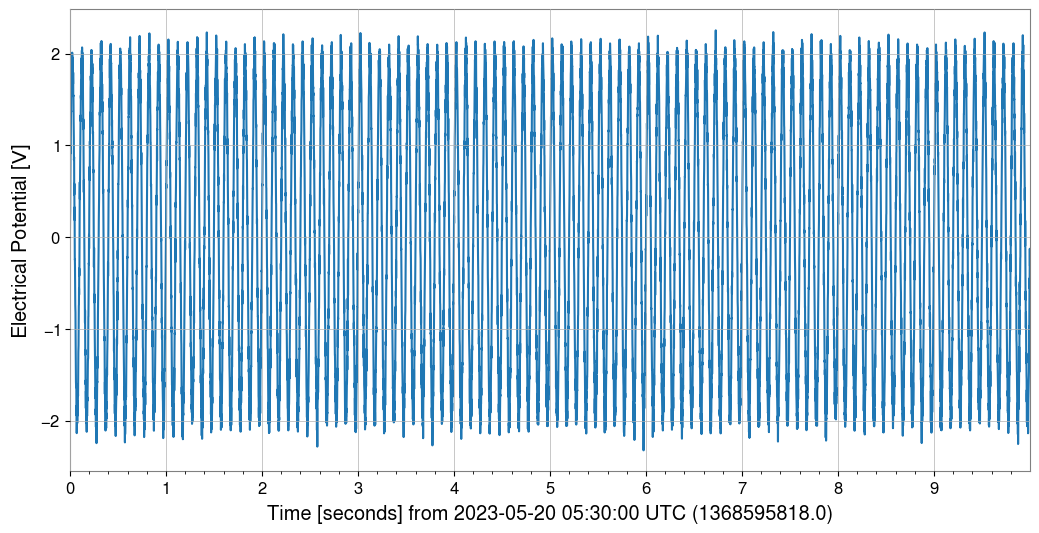

In [5]:
# Read a single TimeSeries
ts_ch0 = TimeSeries.read(
    str(gbd_path),
    format='gbd',
    timezone='Asia/Tokyo',
    channels=['CH0'],
)

print(f"CH0: t0={ts_ch0.t0:.3f}, dt={ts_ch0.dt}, N={len(ts_ch0.value)}")

ts_ch0.plot(xscale='seconds');

## 3. Signal Analysis on GBD Data

Once loaded, all gwexpy analysis methods are available.

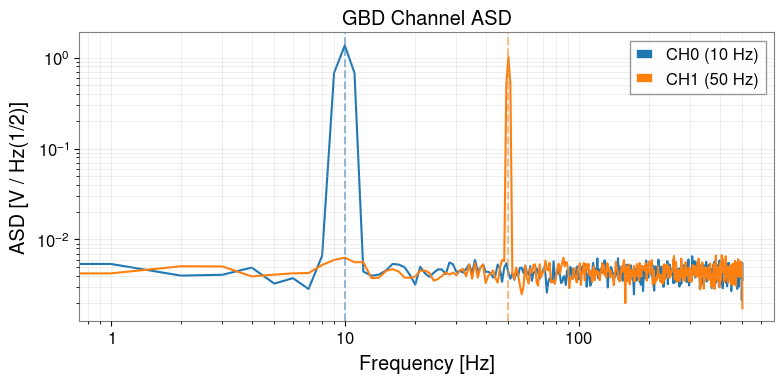

In [6]:
ts_ch0 = tsd['CH0']
ts_ch1 = tsd['CH1']

# ASD comparison
asd_ch0 = ts_ch0.asd(fftlength=1.0, overlap=0.5)
asd_ch1 = ts_ch1.asd(fftlength=1.0, overlap=0.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(asd_ch0.frequencies.value, asd_ch0.value, label='CH0 (10 Hz)')
ax.loglog(asd_ch1.frequencies.value, asd_ch1.value, label='CH1 (50 Hz)')
ax.axvline(10,  color='C0', linestyle='--', alpha=0.5)
ax.axvline(50,  color='C1', linestyle='--', alpha=0.5)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel(f'ASD [{asd_ch0.unit}]')
ax.set_title('GBD Channel ASD')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

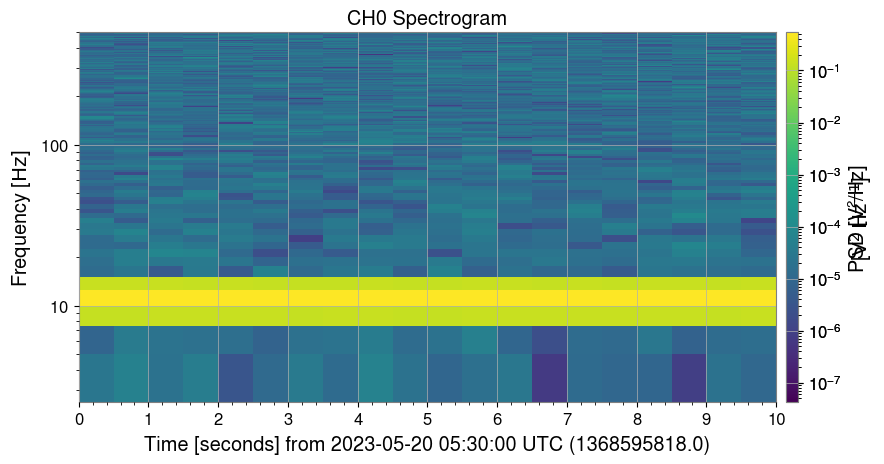

In [7]:
# Spectrogram of CH0
sg = ts_ch0.spectrogram(stride=0.5, fftlength=0.4, overlap=0.2)

plot = sg.plot()
ax = plot.gca()
ax.set_title('CH0 Spectrogram')
plot.colorbar(mappable=plt.gca().get_images()[-1] if plt.gca().get_images() else plt.gca().collections[-1], label=f'PSD [V²/Hz]');

Logic trigger ON events: 10


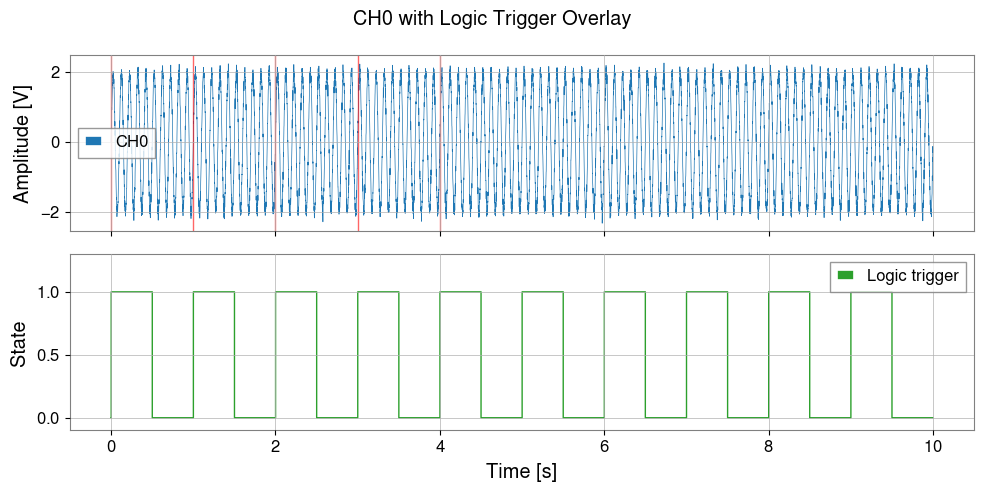

In [8]:
# Digital channel: use as event trigger
ts_logic = tsd['CH2_LOGIC']

# Find trigger-on times (0→1 transitions)
logic_val = ts_logic.value
transitions = np.where(np.diff(logic_val) > 0.5)[0]  # rising edges

t_axis = np.arange(len(logic_val)) * ts_logic.dt.value
trigger_times = t_axis[transitions]

print(f"Logic trigger ON events: {len(trigger_times)}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t_axis, ts_ch0.value, lw=0.5, label='CH0')
for tt in trigger_times[:5]:
    axes[0].axvline(tt, color='red', alpha=0.6, lw=1.0)
axes[0].set_ylabel('Amplitude [V]')
axes[0].legend()

axes[1].step(t_axis, logic_val, where='post', color='C2', lw=1.0, label='Logic trigger')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('State')
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend()

plt.suptitle('CH0 with Logic Trigger Overlay')
plt.tight_layout()

## 4. TimeSeriesMatrix from GBD

For batch multi-channel analysis, load directly into a `TimeSeriesMatrix`.

In [9]:
# Read all analog channels as TimeSeriesMatrix
tsm = TimeSeriesMatrix.read(
    str(gbd_path),
    format='gbd',
    timezone='Asia/Tokyo',
    channels=['CH0', 'CH1'],
)

print("TimeSeriesMatrix shape:", tsm.shape)  # (2, 1, N)

# ASD of all channels at once
try:
    asd_all = tsm.asd(fftlength=1.0, overlap=0.5)
    asd_all.plot(subplots=True)
except AttributeError:
    # GBD reader may create irregular time axis; fall back to per-channel ASD
    _asds = {name: tsd[name].asd(fftlength=1.0, overlap=0.5) for name in list(tsd.keys())[:2]}
    print("Per-channel ASD:", {k: f"{v.df.value:.4f} Hz/bin" for k, v in _asds.items()})

TimeSeriesMatrix shape: (2, 1, 10000)
Per-channel ASD: {'CH0': '1.0000 Hz/bin', 'CH1': '1.0000 Hz/bin'}


## 5. Timezone Handling

GBD files store timestamps in **local time** (the logger's clock). gwexpy converts these to GPS time automatically using the `timezone` parameter.

| Timezone | IANA name | UTC offset |
|----------|-----------|------------|
| Japan Standard Time (KAGRA) | `'Asia/Tokyo'` | +09:00 |
| US Eastern (LIGO Hanford, LLO) | `'US/Eastern'` | −05:00 / −04:00 |
| Europe/Central (Virgo) | `'Europe/Rome'` | +01:00 / +02:00 |
| UTC | `'UTC'` | ±00:00 |

In [10]:
# Check GPS start time resulting from timezone conversion
tsd_jst = TimeSeriesDict.read(str(gbd_path), format='gbd', timezone='Asia/Tokyo')
tsd_utc = TimeSeriesDict.read(str(gbd_path), format='gbd', timezone='UTC')

t0_jst = tsd_jst['CH0'].t0
t0_utc = tsd_utc['CH0'].t0
print(f"t0 (JST→GPS): {t0_jst:.3f}")
print(f"t0 (UTC→GPS): {t0_utc:.3f}")
print(f"Difference: {(t0_jst - t0_utc).value:.1f} s  (should be 9×3600 = 32400 s)")

t0 (JST→GPS): 1368595818.000 s
t0 (UTC→GPS): 1368628218.000 s
Difference: -32400.0 s  (should be 9×3600 = 32400 s)


## 6. Migration Guide: Legacy gbd2gwf.py → gwexpy

**Before (legacy scripts):**
```python
# gbd2gwf.py style
import numpy as np
from gwpy.timeseries import TimeSeries, TimeSeriesDict

# Manual header parsing
with open('data.gbd', 'rb') as f:
    header = f.read(1024).decode('ascii')
    # ... parse Start, Sample, Order, Counts by hand ...
    n_ch = len(channels)
    data = np.frombuffer(f.read(), dtype='<f4').reshape(-1, n_ch)

# Manual GPS time conversion
import pytz
from gwpy.time import to_gps
tz = pytz.timezone('Asia/Tokyo')
t_local = datetime.strptime(start_str, '%Y-%m-%d %H:%M:%S')
t_utc = tz.localize(t_local).astimezone(pytz.utc)
gps_start = to_gps(t_utc.strftime('%Y-%m-%dT%H:%M:%S'))

# Build dict manually
tsd = TimeSeriesDict()
for i, ch in enumerate(channels):
    tsd[ch] = TimeSeries(data[:, i] * scale[i], t0=gps_start, dt=dt)
```

**After (gwexpy):**
```python
from gwexpy.timeseries import TimeSeriesDict

tsd = TimeSeriesDict.read(
    'data.gbd',
    format='gbd',
    timezone='Asia/Tokyo',
)
```

## Summary

| Task | API |
|------|-----|
| Read all channels | `TimeSeriesDict.read(path, format='gbd', timezone='Asia/Tokyo')` |
| Read subset | Add `channels=['CH0', 'CH1']` |
| Read single channel | `TimeSeries.read(path, format='gbd', timezone=..., channels=['CH0'])` |
| Read as matrix | `TimeSeriesMatrix.read(path, format='gbd', timezone=..., channels=...)` |
| Auto-detect digital channels | Channels named `ALARM`, `LOGIC*`, `PULSE*` are binarized |
| Override digital channels | `digital_channels=['CH2_LOGIC', ...]` |
| Override GPS epoch | `epoch=1234567890` (GPS seconds) |

**See also:**
- [Intro TimeSeries](intro_timeseries.ipynb)
- [Interoperability Basics](intro_interop.ipynb)